In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline

In [2]:
#### Convert to DataFrame
wine = pd.DataFrame(load_wine().data, columns = load_wine().feature_names)

In [3]:
wine.shape

(178, 13)

In [4]:
wine.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

### EDA

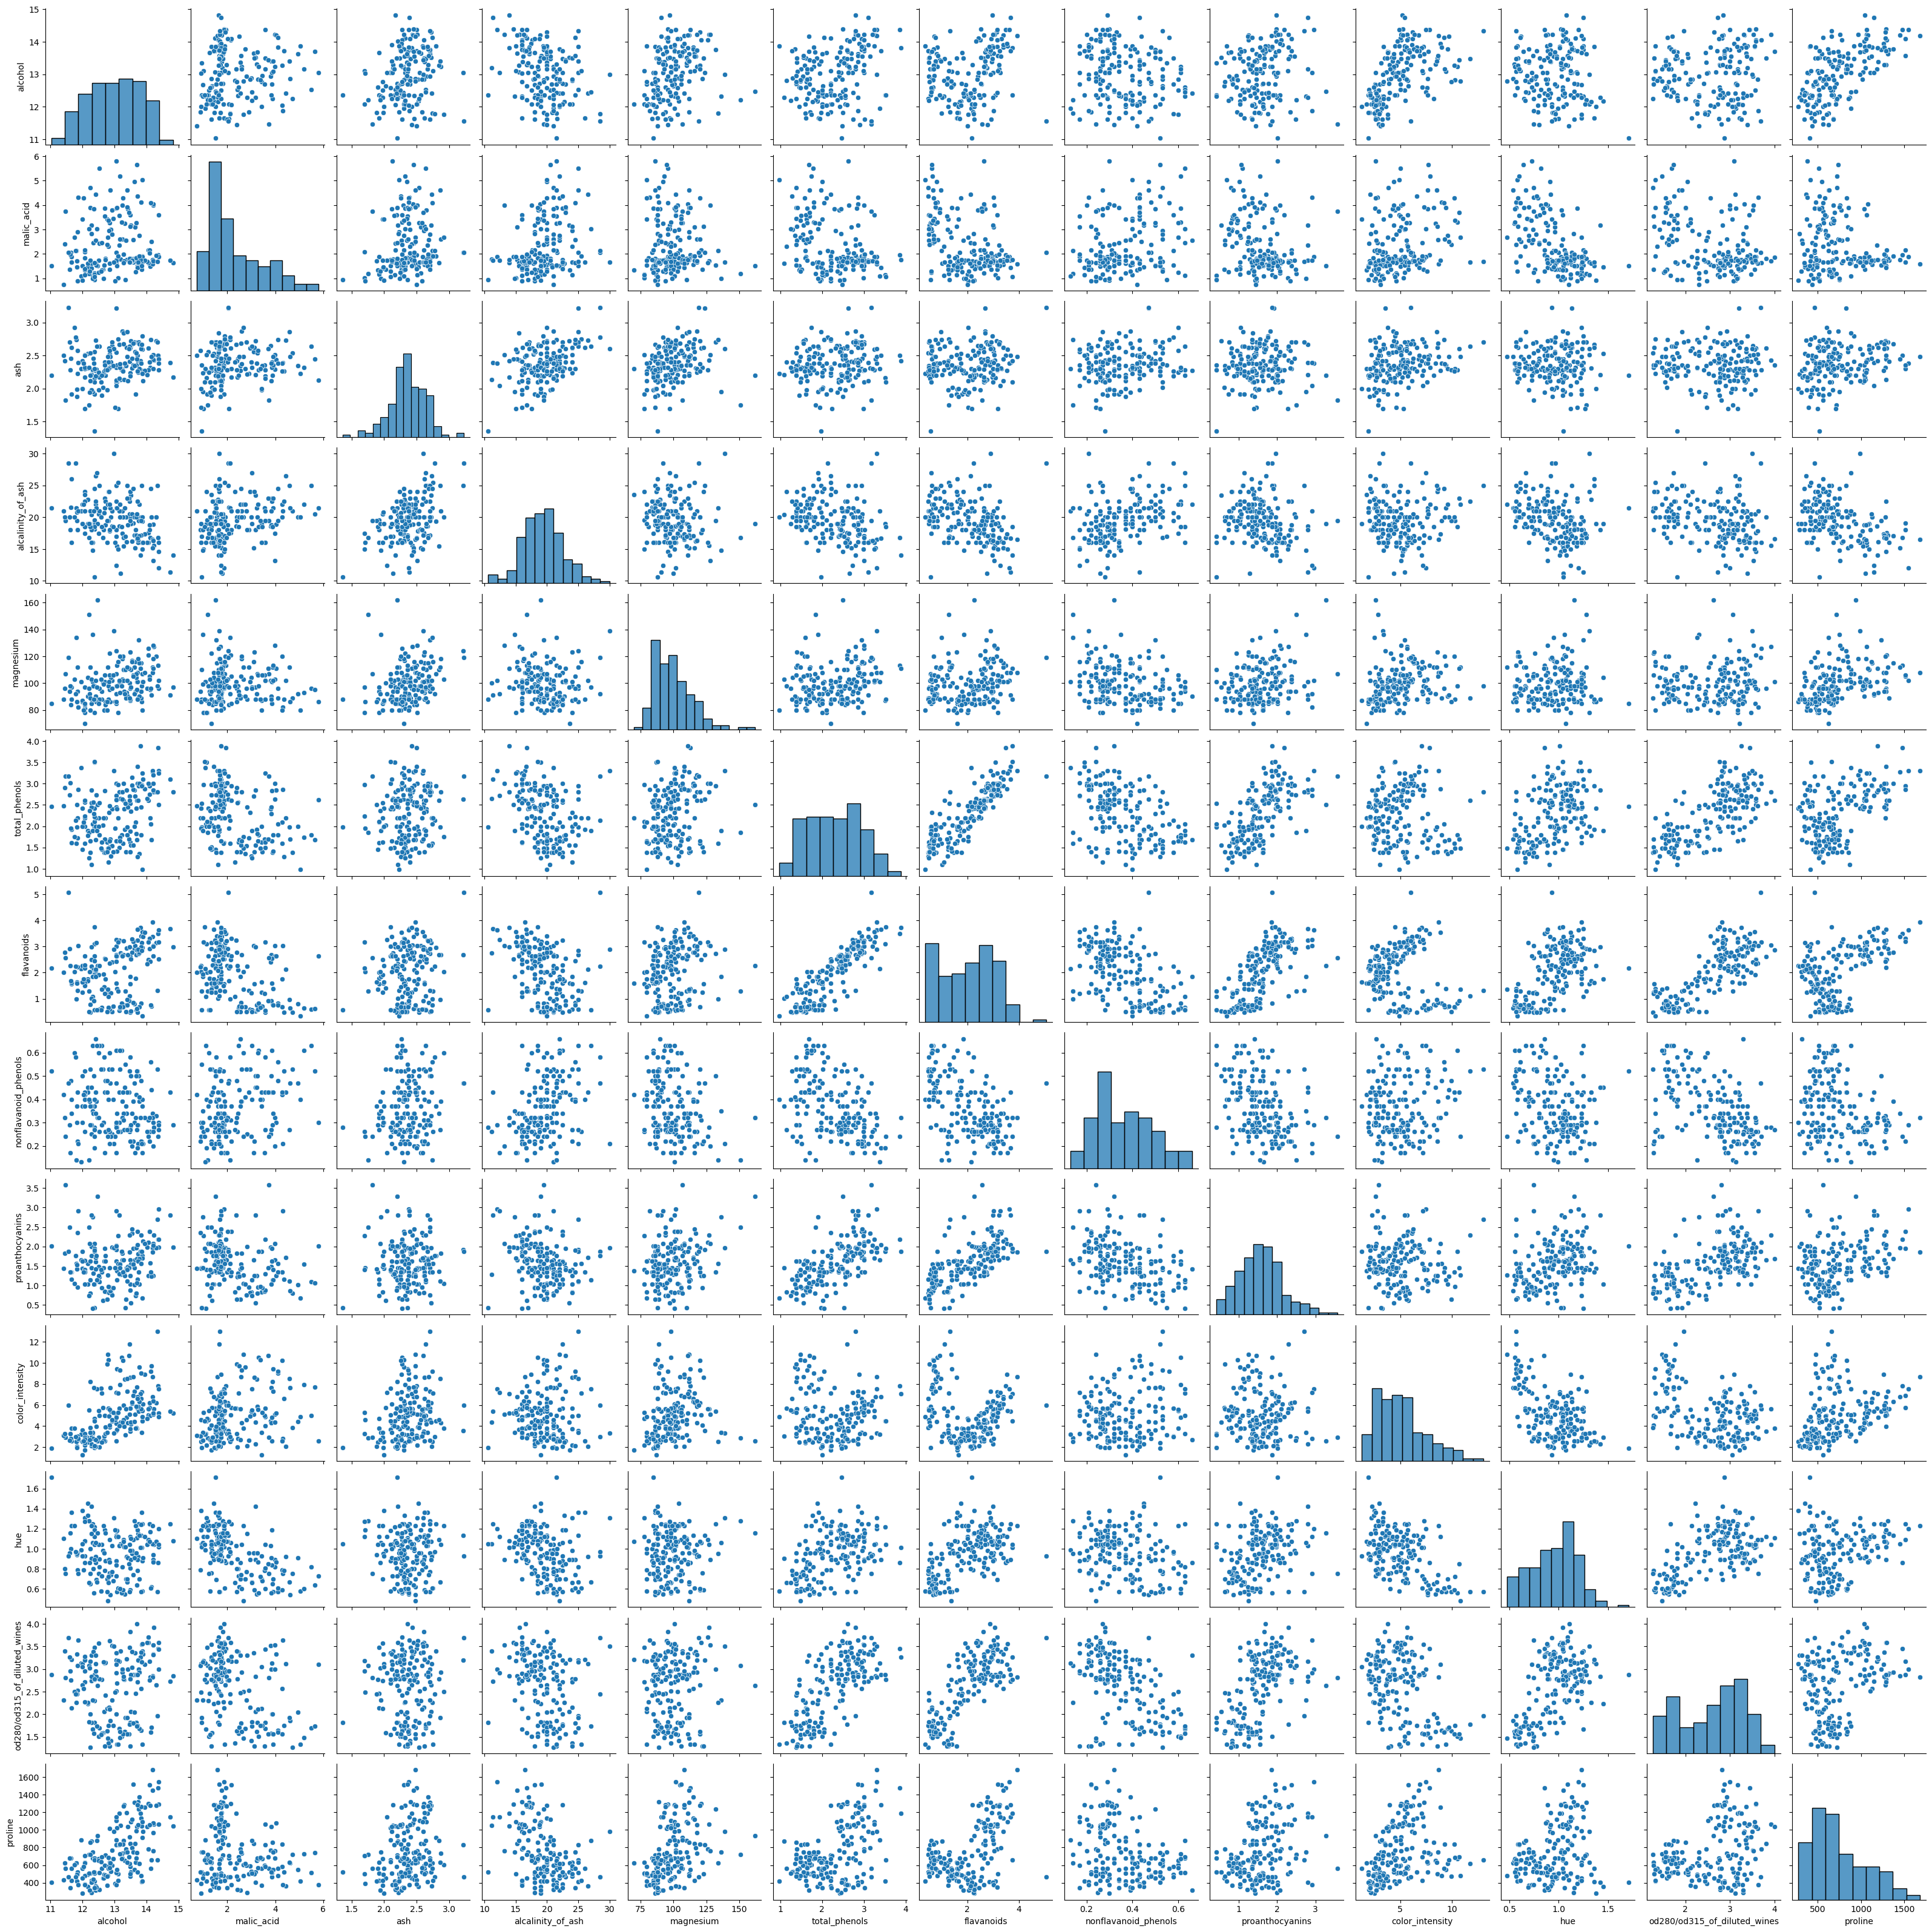

In [5]:
### pairplot
sns.pairplot(wine)
plt.show()

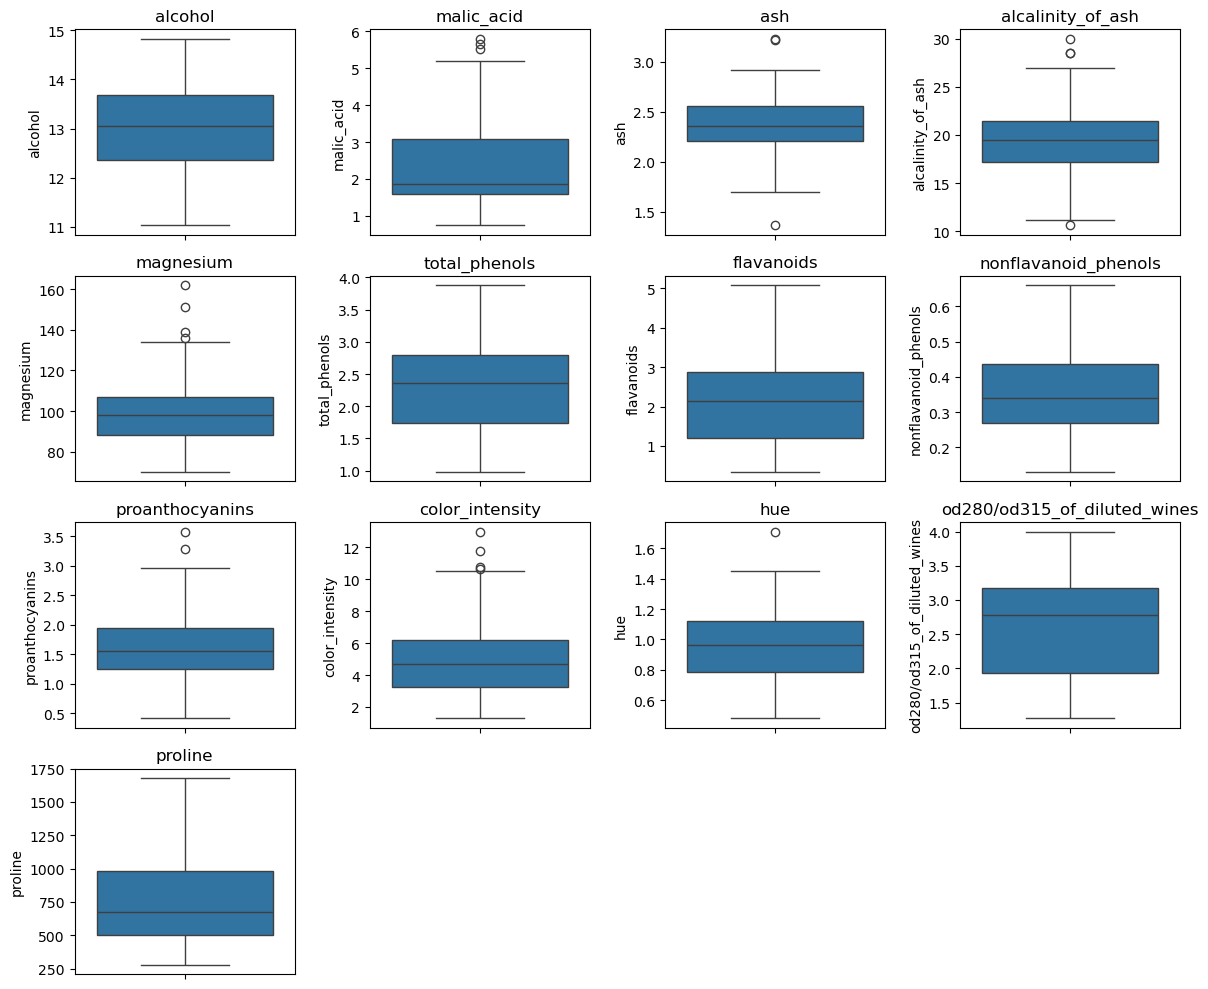

In [6]:
### Boxplot
plt.figure(figsize = (12, 10))
for item, col in enumerate(wine.columns, 1):
    plt.subplot(4,4,item)
    sns.boxplot(wine[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Feature Selection 

In [7]:
x = wine.copy()

In [8]:
x_transform = Pipeline([("scale", StandardScaler())])

In [9]:
x_scaled=x_transform.fit_transform(x)

In [10]:
###scaled_matrix=pd.DataFrame(x_scaled,columns=x.columns)

In [11]:
from scipy.cluster.hierarchy import linkage

In [12]:
tree_data=linkage(x_scaled,method="ward")

In [13]:
from scipy.cluster.hierarchy import dendrogram

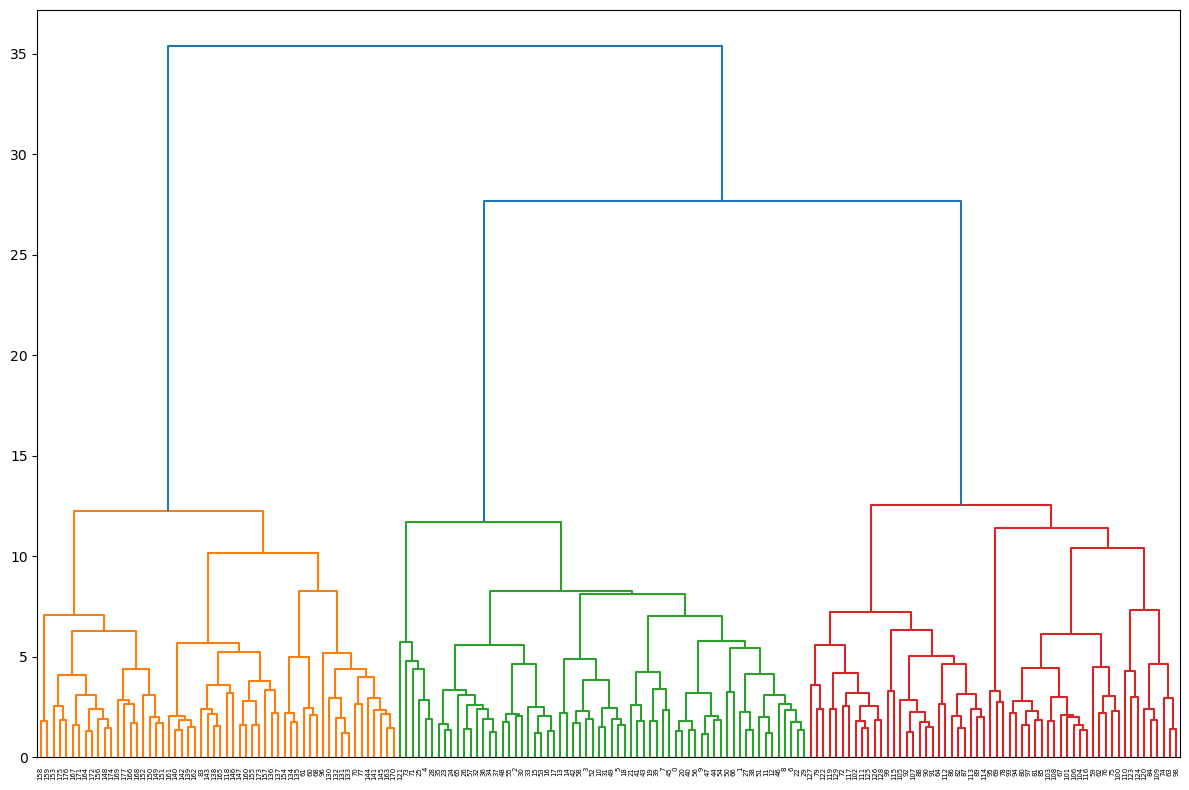

In [14]:
plt.figure(figsize=(12,8))
dendrogram(tree_data)
plt.tight_layout()
plt.show()
           

In [15]:
###
from scipy.cluster.hierarchy import fcluster

In [16]:
fcluster(tree_data,t=27,criterion="distance")

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 1, 1, 3, 3, 3, 2,
       2, 3, 1, 3, 1, 2, 3, 2, 3, 3, 3, 1, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)